In [4]:
import torch
import torch.nn.functional as F
import numpy as np

def router_loss(batch_x, patch_size,eps=1e-12):

        B, T, C = batch_x.shape[:3]
        if T <= 2:  return 0
        gap_batch = batch_x[:, 1:] - batch_x[:, :-1]
       
        # === 2. 通道聚合 (运动强度) ===
        motion = torch.norm(gap_batch, dim=2)         # [B, T-1, H, W]
        # === 3. 时间平均（获得整体运动显著性） ===
        motion = motion.mean(1)                       # [B, H, W]
        # 保证H,W能整除patch_size
        ph, pw = patch_size, patch_size
        motion_patch = motion.unfold(1, ph, ph).unfold(2, pw, pw)  # [B, H/ph, W/pw, ph, pw]
        motion_patch = motion_patch.contiguous().view(B, -1, ph*pw)  # [B, N, ph*pw]
        motion_patch = motion_patch.mean(-1)                        # [B, N]
        # === 4. 展平为 token 维度 ===
        motion = motion_patch.reshape(B, 1, -1)                # [B, N]
        return motion
        # === 5. softmax 得到运动先验分布 ===
        motion_prior = F.softmax(motion / 0.2, dim=-1).detach()   # [B, N]
        total_loss = 0.0
        for i in range(ndepth):
            logits_i = router_logits[i]   # [B, T, N]
            N = logits_i.shape[1]
            # 移除最后那一维（通常是 1）
            logits_i = logits_i.squeeze(-1)   # [B*T, N]
            # 恢复成 [B, T, N]
            logits_i = logits_i.view(B, T, N)

            tau = taus[i]
            # === 6. router 分布 ===
            router_p = F.softmax(logits_i / 0.2, dim=-1)   # [B*T, N]
            # === 7. KL 散度 
            # print('motion_prior:', motion_prior.shape, 'router_p:', router_p.shape)
            loss_i = router_p * torch.log((router_p + eps) / (motion_prior + eps) + eps)

            total_loss += loss_i.mean()

        # === 8. 平均所有层 ===
        total_loss = total_loss / ndepth
        return total_loss

In [9]:
import cv2
import torch
import numpy as np

def flow_magnitude_batch_cuda(batch_x, device_id=0, method="farneback"):
    """
    使用 OpenCV CUDA 计算光流模长（全流程 GPU）
    Args:
        batch_x: torch.Tensor [B, T, C, H, W], 值范围 [0,1] 或 [0,255]
        device_id: int, 指定 GPU 设备 (默认 0)
        method: "tvl1" 或 "farneback"
    Returns:
        flow_mags: torch.Tensor [B, T-1, H, W]
    """
    assert batch_x.ndim == 5, "Expect [B, T, C, H, W]"
    B, T, C, H, W = batch_x.shape

    # 设置 OpenCV CUDA 设备
    cv2.cuda.setDevice(device_id)
    print(f"[INFO] Using OpenCV CUDA device: {device_id}")

    # 选择算法
    if method.lower() == "tvl1":
        flow_estimator = cv2.cuda_OpticalFlowDual_TVL1.create()
    elif method.lower() == "farneback":
        flow_estimator = cv2.cuda_FarnebackOpticalFlow.create(
            numLevels=5, pyrScale=0.5, fastPyramids=False,
            winSize=15, numIters=3, polyN=5, polySigma=1.2, flags=0)
    else:
        raise ValueError("method 必须是 'tvl1' 或 'farneback'")

    flow_mags = []

    # 将 Tensor 转为 GPU numpy（避免 CPU 拷贝）
    batch_x = (batch_x * 255).clamp(0, 255).byte().permute(0, 1, 3, 4, 2).contiguous()  # [B,T,H,W,C]
    batch_x = batch_x.detach().to("cpu").numpy()  # ⚠️ OpenCV 目前不支持 torch.cuda.Tensor

    for b in range(B):
        mags_b = []
        for t in range(T - 1):
            frame1 = batch_x[b, t]
            frame2 = batch_x[b, t + 1]

            # 灰度化
            if C > 1:
                frame1 = cv2.cvtColor(frame1, cv2.COLOR_RGB2GRAY)
                frame2 = cv2.cvtColor(frame2, cv2.COLOR_RGB2GRAY)
            else:
                frame1 = frame1.squeeze(-1)
                frame2 = frame2.squeeze(-1)

            # 上传到 GPU（指定设备）
            gpu_prev = cv2.cuda_GpuMat()
            gpu_next = cv2.cuda_GpuMat()
            gpu_prev.upload(frame1)
            gpu_next.upload(frame2)

            # 计算光流（GPU）
            gpu_flow = flow_estimator.calc(gpu_prev, gpu_next, None)

            # 直接在 GPU 上计算模长
            gpu_flow_x = cv2.cuda.split(gpu_flow)[0]
            gpu_flow_y = cv2.cuda.split(gpu_flow)[1]
            gpu_mag, _ = cv2.cuda.cartToPolar(gpu_flow_x, gpu_flow_y, angleInDegrees=False)

            # 下载结果到 CPU (最后一步)
            mag = gpu_mag.download()
            mags_b.append(mag)

        flow_mags.append(np.stack(mags_b, axis=0))  # [T-1,H,W]

    flow_mags = torch.from_numpy(np.stack(flow_mags, axis=0)).float().to(f"cuda:{device_id}")
    return flow_mags


In [8]:
from torchvision.models.optical_flow import raft_small, Raft_Small_Weights

# 全局缓存
_RAFT_MODEL = None
_RAFT_DEVICE = None

def torch_flow_mag_raft(batch_x, fp16=False):
        """
        使用 RAFT small 模型计算相邻帧光流模长（支持多 GPU 自适应）
        Args:
            batch_x: [B, T, C, H, W] torch.Tensor, dtype=float32, [0,1]
            fp16: 是否使用半精度加速
        Returns:
            flow_mag: [B, T-1, H, W]
        """
        global _RAFT_MODEL, _RAFT_DEVICE

        # --- 确保模型只加载一次 ---
        device = batch_x.device
        if (_RAFT_MODEL is None) or (_RAFT_DEVICE != device):
            weights = Raft_Small_Weights.C_T_V1
            model = raft_small(weights=weights).to(device).eval()
            if fp16:
                model = model.half()
            _RAFT_MODEL = model
            _RAFT_DEVICE = device

        B, T, C, H, W = batch_x.shape
        flow_mags = []

        with torch.no_grad():
            for t in range(T - 1):
                x1, x2 = batch_x[:, t], batch_x[:, t + 1]
                if fp16:
                    x1, x2 = x1.half(), x2.half()

                # 模型前向，自动在 batch_x.device 上运行
                flow_out = _RAFT_MODEL(x1, x2)
                # torchvision RAFT 返回 {"flow": tensor}
                if isinstance(flow_out, dict):
                    flow = flow_out["flow"]
                else:
                    flow = flow_out[-1]

                flow_mag = flow.norm(dim=1)  # [B, H, W]
                flow_mags.append(flow_mag)

        return torch.stack(flow_mags, dim=1)  # [B, T-1, H, W]

In [5]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def plot_tensor_curve(tensor, normalize=False):
    """
    绘制形状 [B, 1, L] 的 tensor 的曲线分布（2x4 布局）

    Args:
        tensor (torch.Tensor): 输入张量 [B, 1, L]
        normalize (bool): 是否对每个样本归一化到 [0,1]
    """
    tensor = tensor.detach().cpu().squeeze(1)  # [B, L]
    B, L = tensor.shape
    x_axis = np.arange(L)

    fig, axes = plt.subplots(2, 4, figsize=(18, 6))
    axes = axes.flatten()

    for i in range(B):
        y = tensor[i].numpy()
        if normalize:
            y = (y - y.min()) / (y.max() - y.min() + 1e-8)

        ax = axes[i]
        ax.plot(x_axis, y, color='tomato', linewidth=1.2)
        ax.fill_between(x_axis, y, alpha=0.2, color='tomato')  # 加半透明区域
        ax.set_title(f'Sample {i} | min={y.min():.2e}, max={y.max():.2e}', fontsize=10)
        ax.set_xlim(0, L - 1)
        ax.grid(True, linestyle='--', alpha=0.4)

    for j in range(B, 8):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# # 示例
# x = torch.randn(8, 1, 1024).abs() * 0.05
# plot_tensor_curve(x)


In [6]:
import sys
sys.path.append('/nas_data/LSH/OpenSTL-MOR')
from openstl.datasets.dataloader_human import load_data

dataloader_train, _, dataloader_test = \
        load_data(batch_size=8,
                  val_batch_size=4,
                  data_root='/nas_data/LSH/data/',
                  num_workers=4,
                  pre_seq_length=4, aft_seq_length=4,
                  use_prefetcher=True, distributed=False)

print(len(dataloader_train), len(dataloader_test))
for item in dataloader_train:
    print(item[0].shape, item[1].shape)
    batch_x = item[0]
    batch_y = item[1]
    motion_logits = router_loss(batch_x=batch_x, patch_size=8)
    print(motion_logits.shape)
    break




/home/server/anaconda3/envs/lsh_openstl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


9175 2146
torch.Size([8, 4, 3, 256, 256]) torch.Size([8, 4, 3, 256, 256])
torch.Size([8, 1, 1024])


## Ori Logits

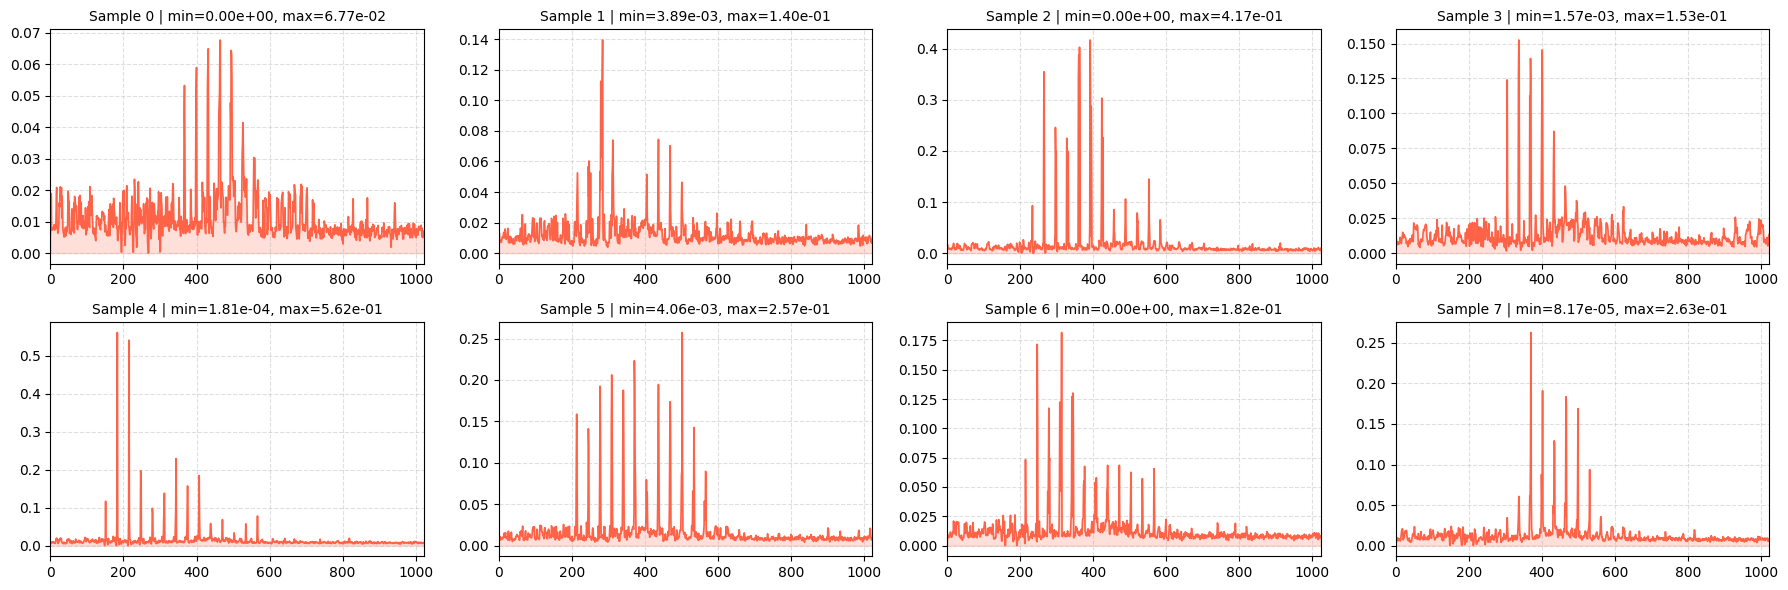

In [7]:
plot_tensor_curve(motion_logits)

## Softmax Logits tau 0.2

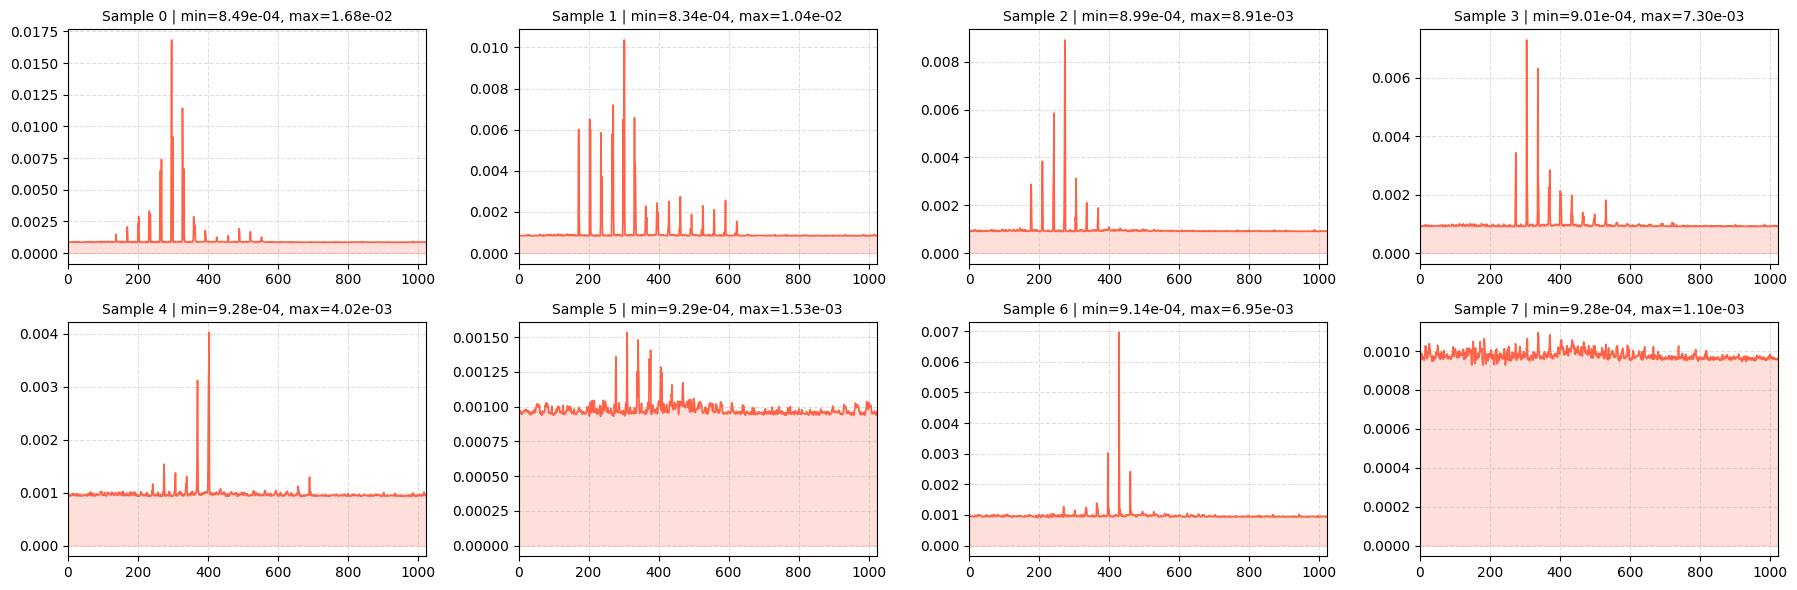

In [16]:
## Softmax Logits tau 0.2
plot_tensor_curve(F.softmax(motion_logits / 0.2, dim=-1))

## Softmax Logits tau 0.1

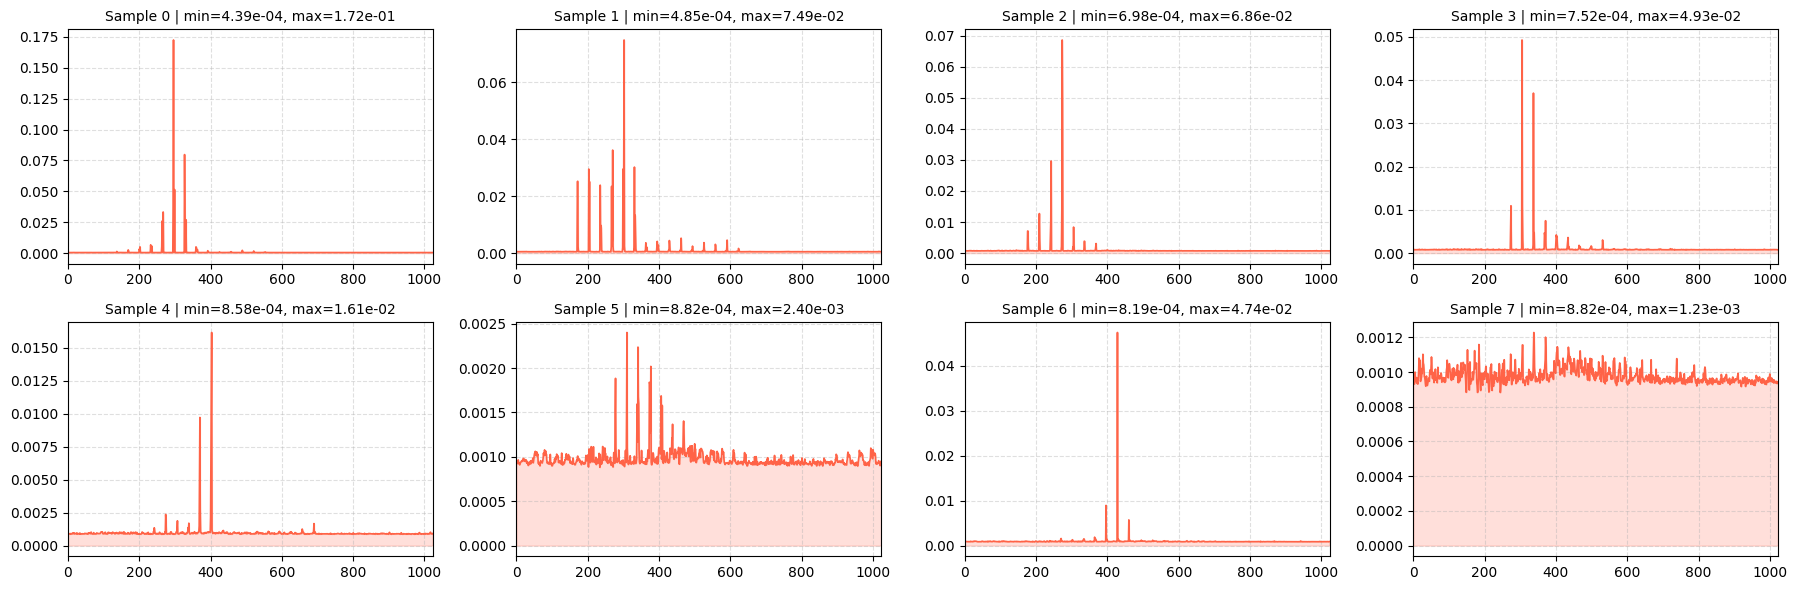

In [17]:
plot_tensor_curve(F.softmax(motion_logits / 0.1, dim=-1))

## Softmax Logits tau 0.3

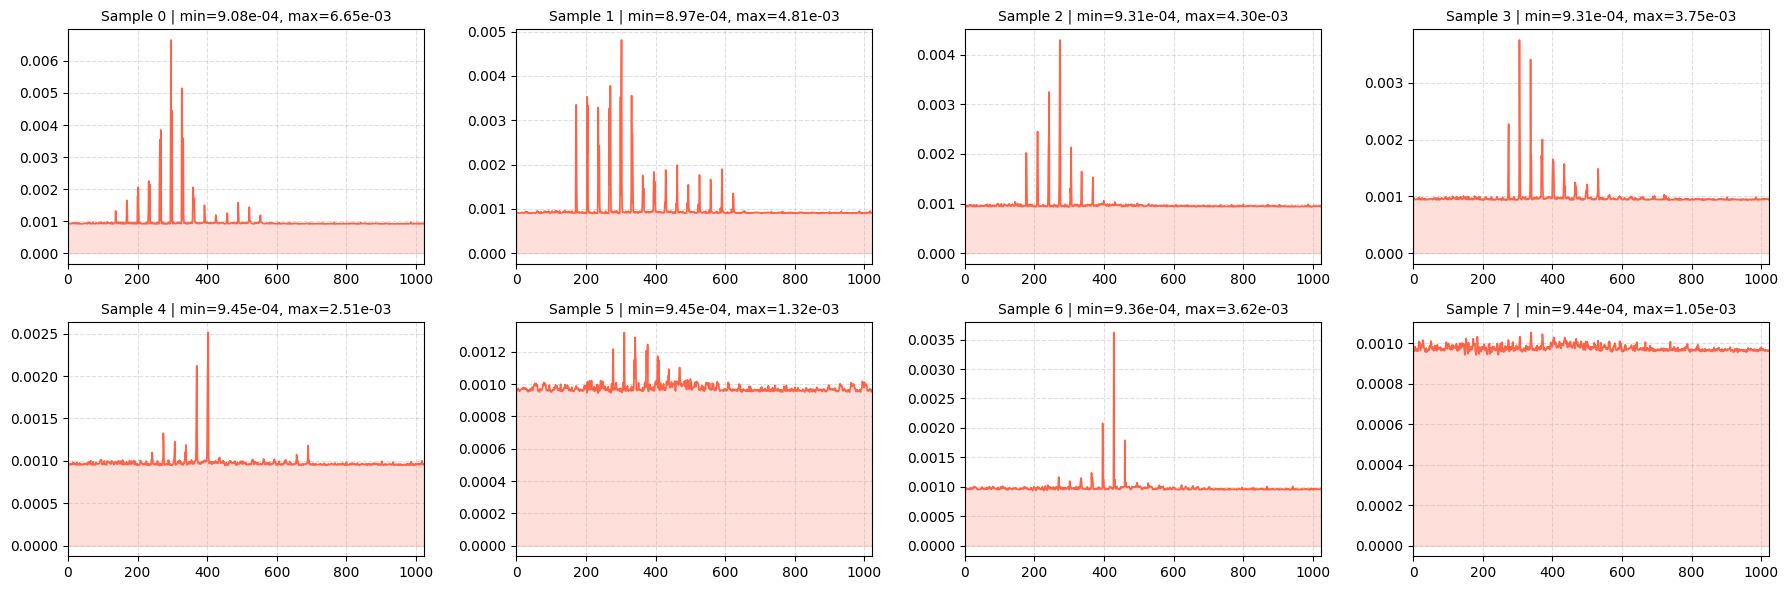

In [18]:
plot_tensor_curve(F.softmax(motion_logits / 0.3, dim=-1))

## Batch_x

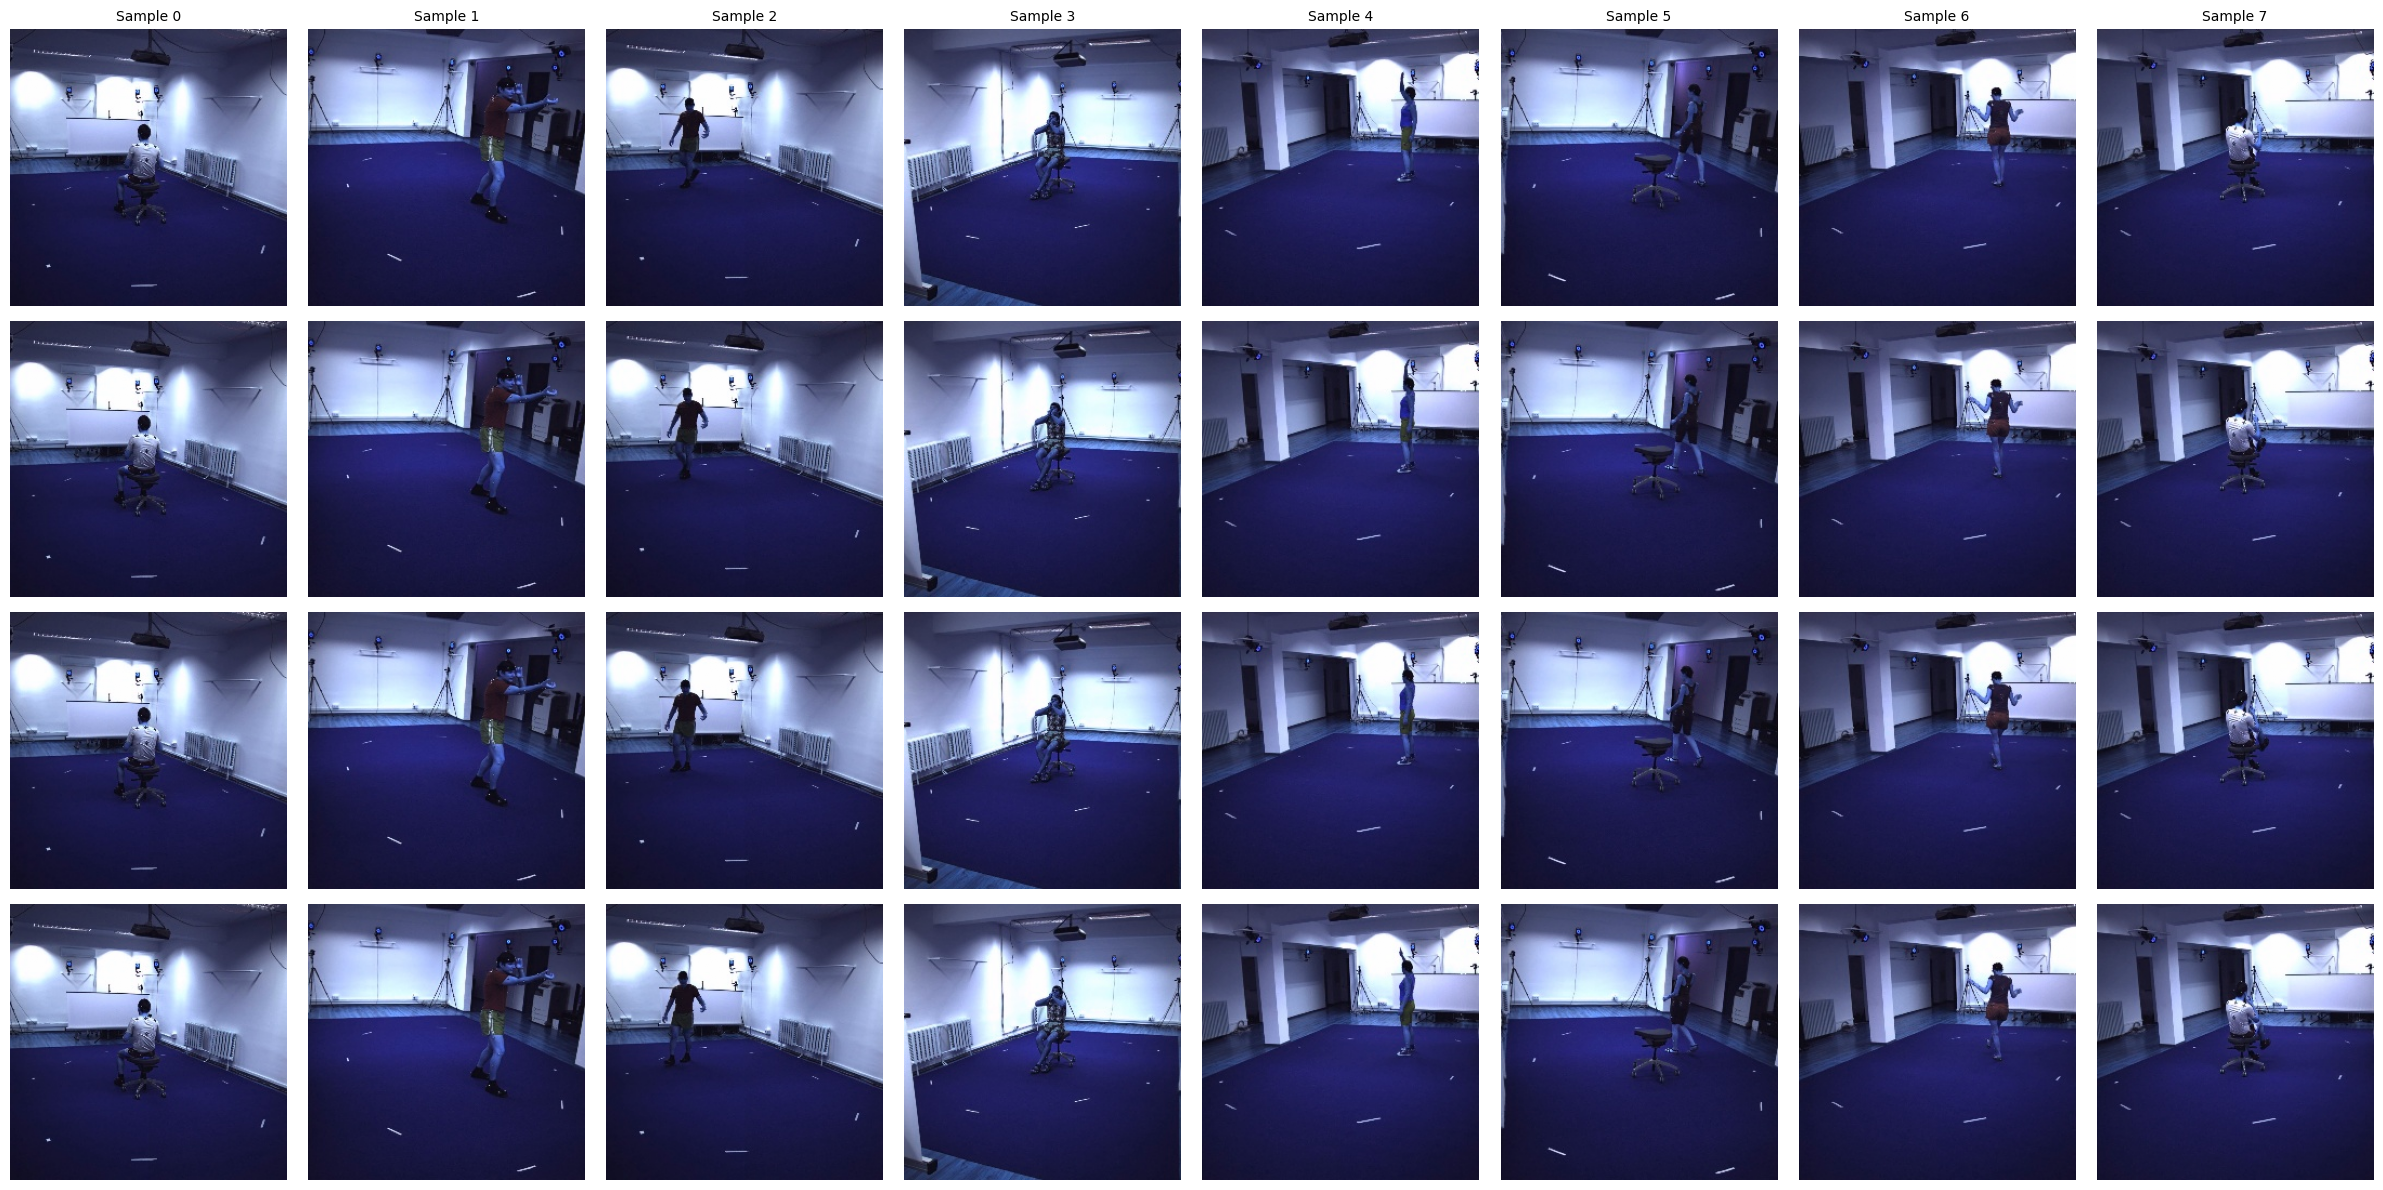

In [8]:
import torch
import matplotlib.pyplot as plt

def visualize_tensor_grid(tensor, normalize=True):
    """
    可视化 [B, T, C, H, W] 形状的张量为 4x8 图像网格
    每行代表时间帧，每列代表样本
    """
    tensor = tensor.detach().cpu()
    B, T, C, H, W = tensor.shape
    assert T == 4 and B == 8, f"当前支持 4x8 网格，可根据需要调整 T={T}, B={B}"

    fig, axes = plt.subplots(T, B, figsize=(3 * B, 3 * T))
    plt.subplots_adjust(wspace=0.05, hspace=0.05)

    for t in range(T):
        for b in range(B):
            img = tensor[b, t]  # [C, H, W]
            if normalize:
                img_min, img_max = img.min(), img.max()
                img = (img - img_min) / (img_max - img_min + 1e-8)

            img_np = img.permute(1, 2, 0).numpy()  # [H, W, C]
            ax = axes[t, b]
            ax.imshow(img_np)
            ax.axis('off')
            if t == 0:
                ax.set_title(f"Sample {b}", fontsize=10)

        axes[t, 0].set_ylabel(f"Frame {t}", fontsize=10, rotation=90, labelpad=10)

    plt.tight_layout()
    plt.show()

# 示例调用
# x = torch.randn(8, 4, 3, 256, 256)
visualize_tensor_grid(batch_x)


# 光流

## Ori Logits

[INFO] Using OpenCV CUDA device: 0


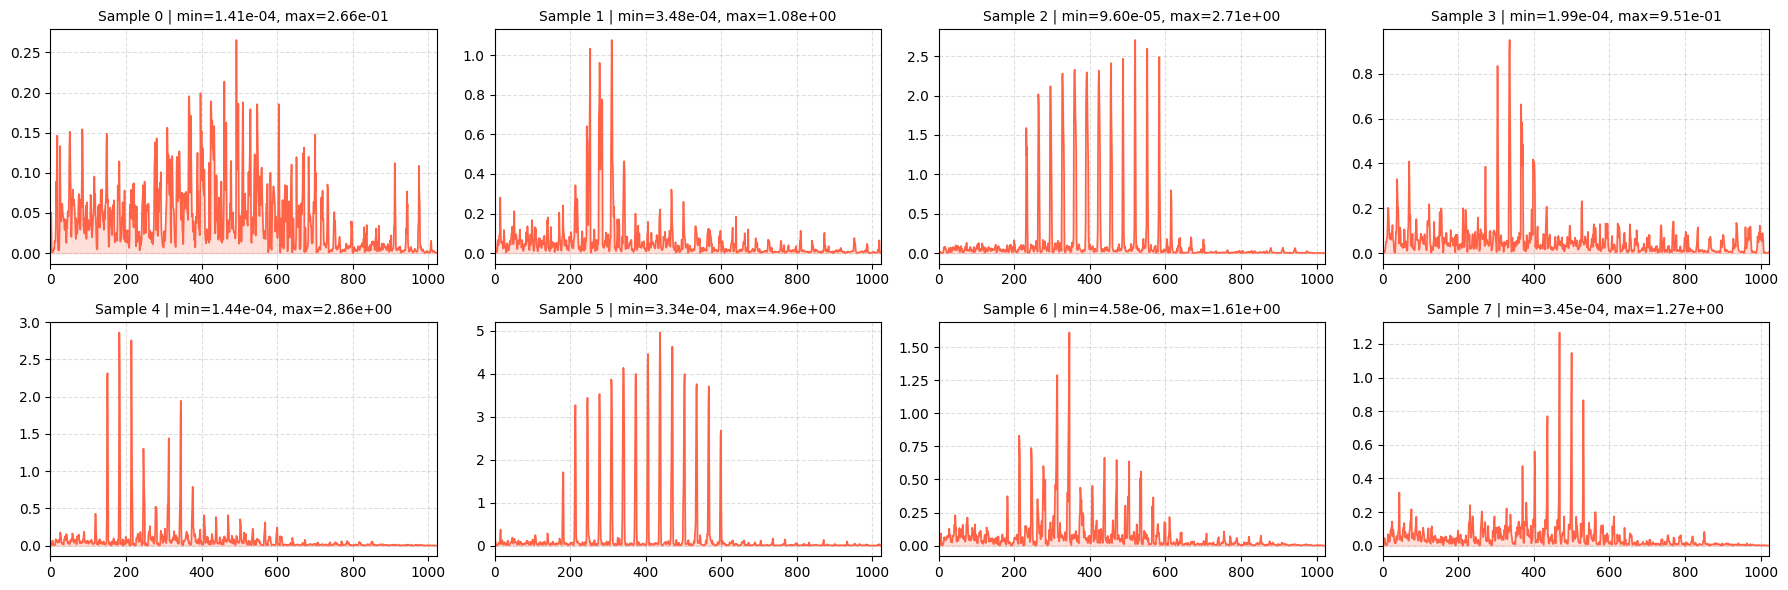

: 

In [ ]:
# === 计算光流模长 ===
flow_mag = flow_magnitude_batch_cuda(batch_x)  # [B, T-1, H, W]

# === patch pooling ===
flow_mag_mean = flow_mag.mean(1)  # [B, H, W]
ph = pw = 8
B = 8
flow_patch = flow_mag_mean.unfold(1, ph, ph).unfold(2, pw, pw)
flow_patch = flow_patch.contiguous().view(B, -1, ph*pw).mean(-1)  # [B, N]

# === softmax 生成 motion_prior ===
# motion_prior = F.softmax(flow_patch / 0.3, dim=-1).detach()  # [B, N]
plot_tensor_curve(flow_patch)

## Ori Logits raft

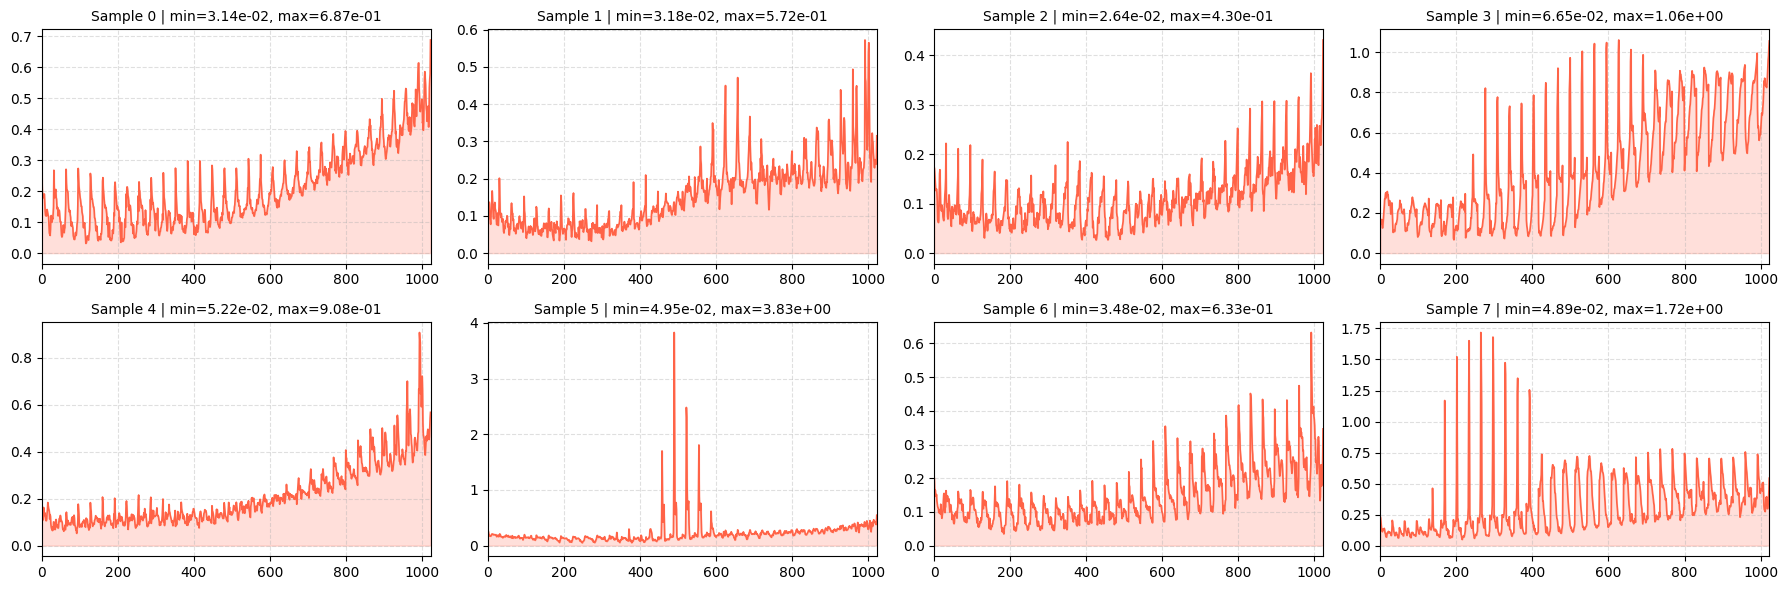

In [16]:
# === 计算光流模长 ===
flow_mag = torch_flow_mag_raft(batch_x, fp16=False)  # [B, T-1, H, W]

# === patch pooling ===
flow_mag_mean = flow_mag.mean(1)  # [B, H, W]
ph = pw = 8
B = 8
flow_patch = flow_mag_mean.unfold(1, ph, ph).unfold(2, pw, pw)
flow_patch = flow_patch.contiguous().view(B, -1, ph*pw).mean(-1)  # [B, N]

# === softmax 生成 motion_prior ===
# motion_prior = F.softmax(flow_patch / 0.3, dim=-1).detach()  # [B, N]
plot_tensor_curve(flow_patch)

## Softmax Logits tau 0.2

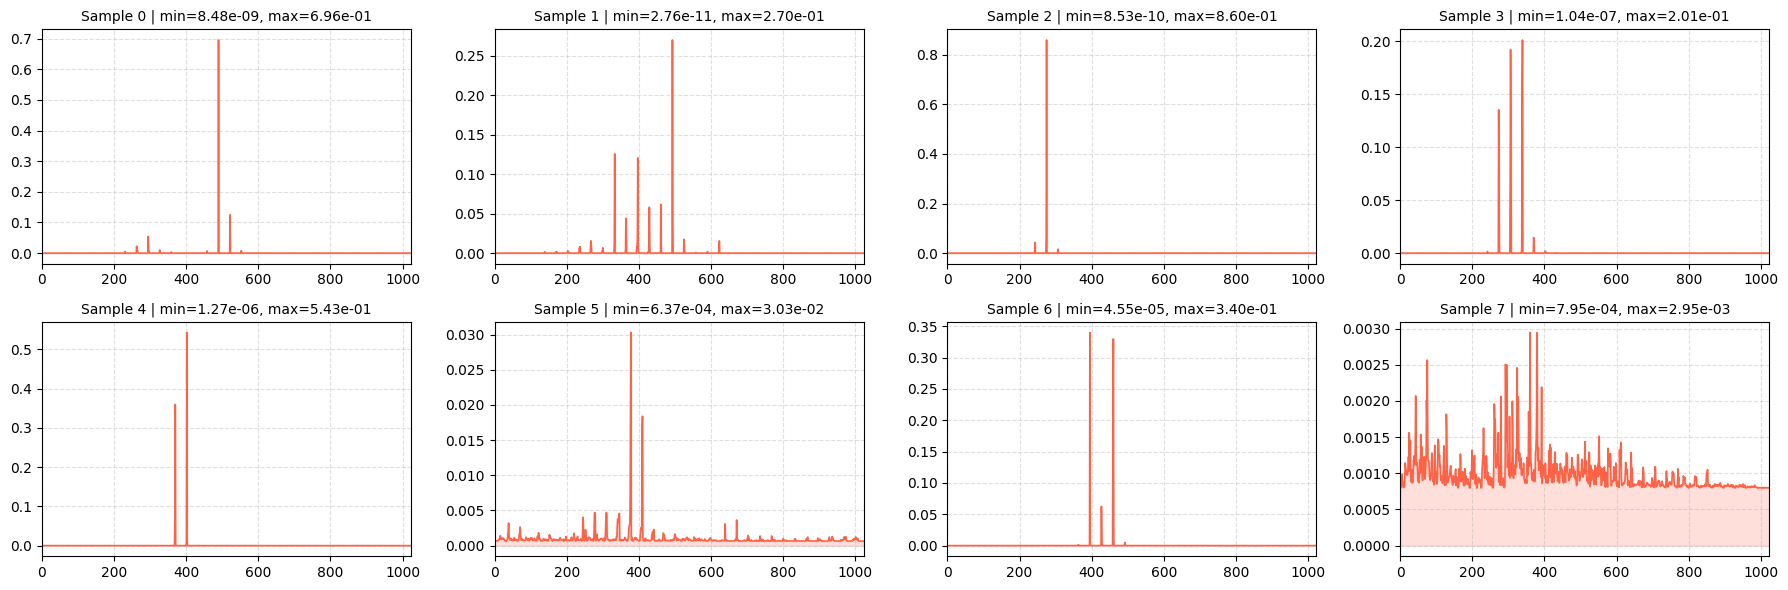

: 

In [ ]:
plot_tensor_curve(F.softmax(flow_patch / 0.2, dim=-1))

In [1]:
import cv2
# print("OpenCV version:", cv2.__version__)

if cv2.cuda.getCudaEnabledDeviceCount() > 0:
    print("✅ CUDA is available in OpenCV!")
else:
    print("❌ OpenCV was built without CUDA support.")


✅ CUDA is available in OpenCV!
